Combined speech enhancement + FxLMS headphone ANC test
-------------------------------------------------------
Speech mic input SNR:                 0.000 dB
After online speech enhancement:      6.900 dB
Ear input SNR before ANC:             2.356 dB
Ear output SNR after FxLMS ANC:       5.559 dB
Final ear noise power before ANC:  1.042122
Final residual power after ANC:    0.078206
Full-system distortion:            0.278053

Shape/finite-value tests passed.
Speech enhancement SNR test passed.
FxLMS ANC residual-power test passed.


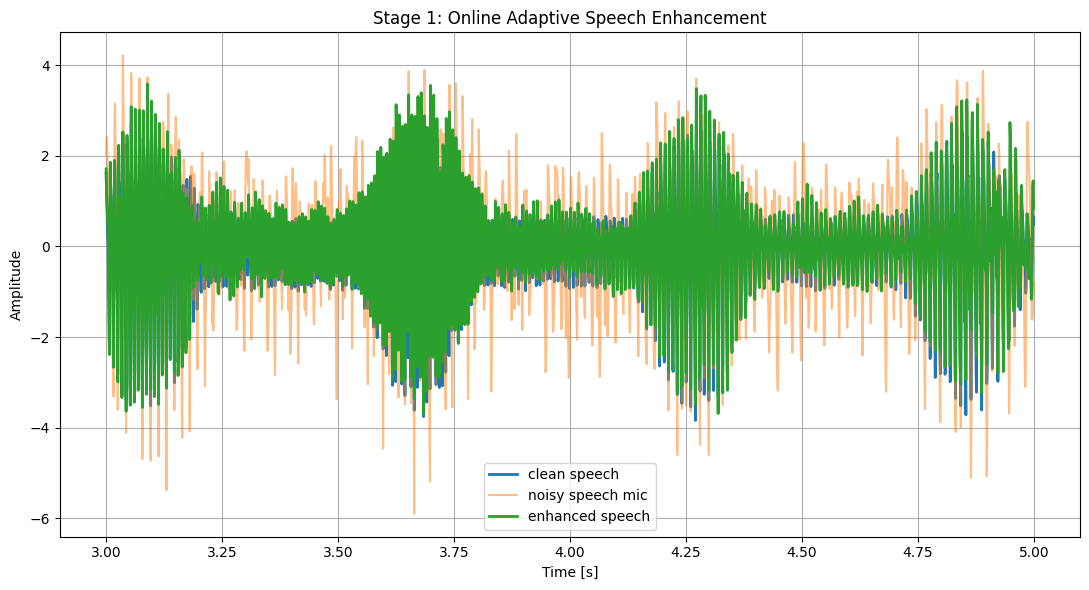

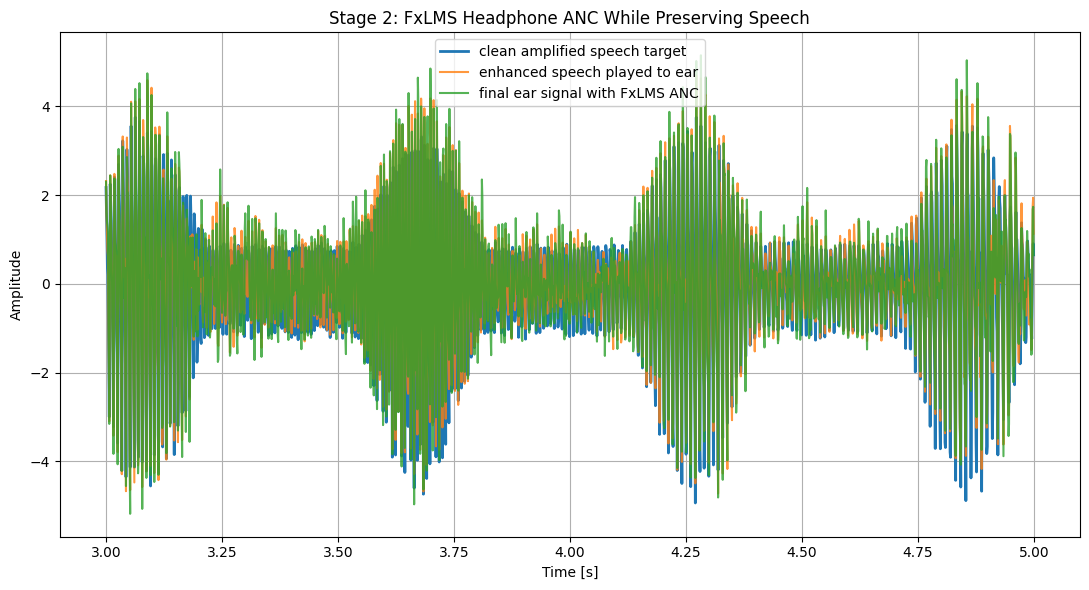

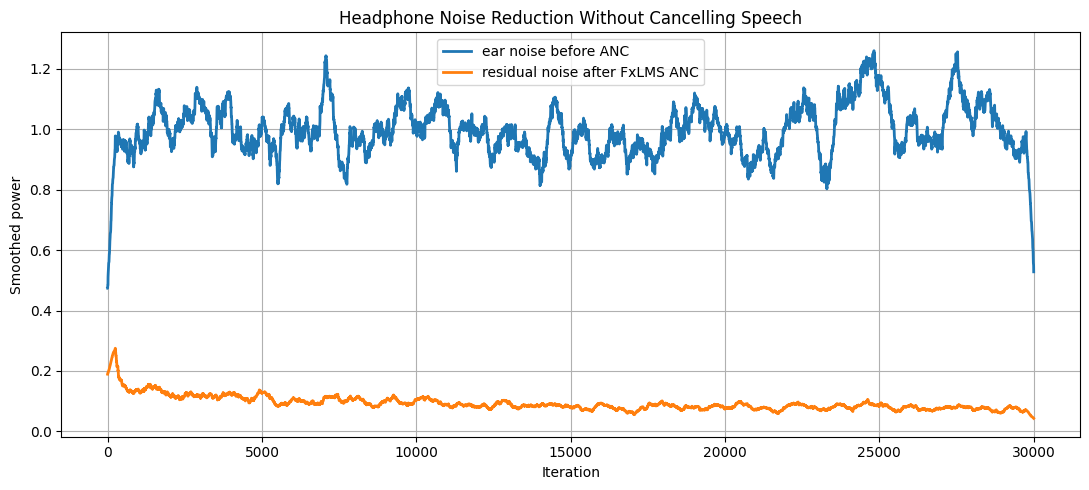

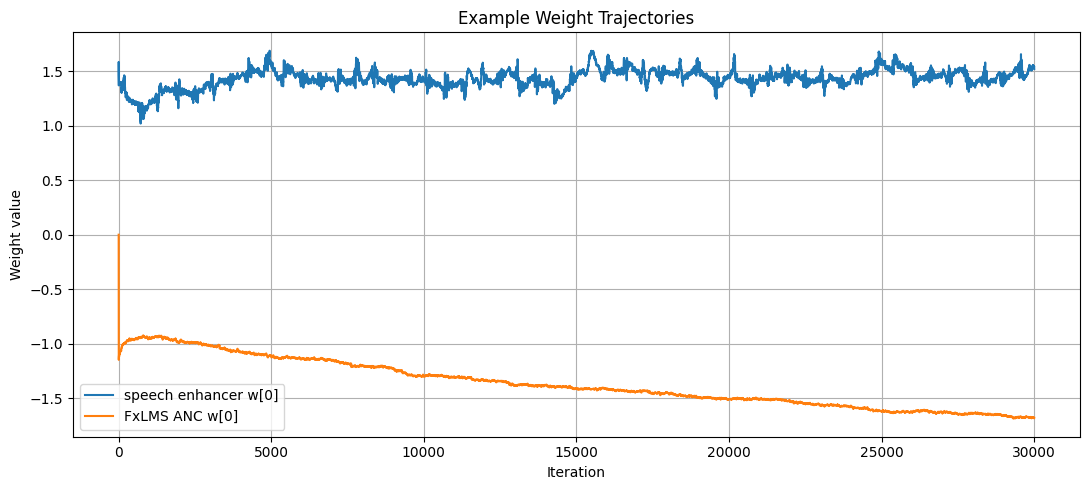

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================
# Helper functions
# =================================================

def past_vector(signal, n, L):
    """
    Returns [signal[n], signal[n-1], ..., signal[n-L+1]]
    with zero-padding for negative indices.
    """
    vec = np.zeros(L)
    for k in range(L):
        if n - k >= 0:
            vec[k] = signal[n - k]
    return vec


def moving_average(x, window):
    """
    Simple moving average for smoother plots.
    """
    window = min(window, len(x))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


def fir_filter(x, h):
    """
    Causal FIR filtering using convolution.
    Output has same length as x.
    """
    return np.convolve(x, h, mode="full")[: len(x)]


def normalize(x, eps=1e-12):
    """
    Normalize signal to unit RMS.
    """
    return x / (np.sqrt(np.mean(x**2)) + eps)


def scale_noise_to_snr(clean, noise, snr_db_value, eps=1e-12):
    """
    Scale noise so clean + noise has the desired SNR.
    """
    clean_power = np.mean(clean**2)
    noise_power = np.mean(noise**2) + eps
    target_noise_power = clean_power / (10 ** (snr_db_value / 10))
    scale = np.sqrt(target_noise_power / noise_power)
    return scale * noise, scale


def snr_db(clean, test, eps=1e-12):
    """
    SNR between a clean target and a test signal.
    Higher is better.
    """
    error = test - clean
    return 10 * np.log10((np.sum(clean**2) + eps) / (np.sum(error**2) + eps))


def speech_distortion(clean, test, eps=1e-12):
    """
    Normalized squared error relative to clean speech.
    Smaller is better.
    """
    return np.sum((clean - test) ** 2) / (np.sum(clean**2) + eps)


# =================================================
# Synthetic signals
# =================================================

def make_synthetic_speech(fs, T, seed=10):
    """
    Creates a speech-like signal.

    It is not real recorded speech, but it has:
    - voiced harmonic content,
    - slowly changing pitch,
    - syllable-like amplitude envelope,
    - small unvoiced/noisy components.
    """
    rng = np.random.default_rng(seed)

    N = int(fs * T)
    t = np.arange(N) / fs

    f0 = 110 + 30 * np.sin(2 * np.pi * 0.35 * t) + 10 * np.sin(2 * np.pi * 0.9 * t)
    phase = 2 * np.pi * np.cumsum(f0) / fs

    voiced = (
        1.00 * np.sin(phase)
        + 0.50 * np.sin(2 * phase + 0.3)
        + 0.25 * np.sin(3 * phase + 0.7)
        + 0.15 * np.sin(4 * phase + 1.1)
    )

    envelope = 0.25 + 0.75 * np.maximum(0, np.sin(2 * np.pi * 1.7 * t)) ** 1.5

    unvoiced = fir_filter(rng.standard_normal(N), np.array([1.0, -0.8]))
    unvoiced = normalize(unvoiced)

    speech = envelope * voiced + 0.08 * envelope * unvoiced
    return normalize(speech)


def make_engine_like_noise(fs, T, seed=20):
    """
    Creates colored fan/engine-like noise with tonal components.
    """
    rng = np.random.default_rng(seed)
    N = int(fs * T)
    t = np.arange(N) / fs

    white = rng.standard_normal(N)
    h_col = np.array([0.05, 0.10, 0.16, 0.20, 0.16, 0.10, 0.05])
    colored = fir_filter(white, h_col)

    tonal = (
        1.0 * np.sin(2 * np.pi * 60 * t)
        + 0.5 * np.sin(2 * np.pi * 120 * t + 0.4)
        + 0.25 * np.sin(2 * np.pi * 180 * t + 1.2)
    )

    noise = colored + 0.8 * tonal
    return normalize(noise)


# =================================================
# Combined system under test
# =================================================

def run_speech_enhancement_plus_fxlms_headphone(
    speech,
    speech_primary_noise,
    speech_reference_noise,
    ear_noise,
    anc_reference_noise,
    secondary_path,
    secondary_path_hat,
    playback_path,
    M_enhance,
    M_anc,
    mu_enhance,
    mu_anc,
    speech_gain=1.0,
    normalized=True,
):
    """
    Combined two-stage system.

    Stage 1:
        1975-style online adaptive noise canceller.
        Primary microphone = speech + speech_primary_noise.
        Reference microphone = correlated noise reference.
        Output = enhanced_speech.

    Stage 2:
        FxLMS headphone active noise cancellation.
        Enhanced speech is played through the headphone.
        FxLMS cancels ear noise while preserving enhanced speech.

    The clean speech is not used for adaptation.
    It is only used outside this function for testing/evaluation.
    """
    N = len(speech)

    # -------------------------------------------------
    # Stage 1: Online speech enhancement
    # -------------------------------------------------
    w_enhance = np.zeros(M_enhance)

    noisy_speech_mic = speech + speech_primary_noise
    estimated_speech_noise = np.zeros(N)
    enhanced_speech = np.zeros(N)
    w_enhance_hist = np.zeros((N, M_enhance))

    eps = 1e-8

    for n in range(N):
        n_r_vec = past_vector(speech_reference_noise, n, M_enhance)

        estimated_speech_noise[n] = np.dot(w_enhance, n_r_vec)
        enhanced_speech[n] = noisy_speech_mic[n] - estimated_speech_noise[n]

        if normalized:
            denom = eps + np.dot(n_r_vec, n_r_vec)
            w_enhance = w_enhance + mu_enhance * enhanced_speech[n] * n_r_vec / denom
        else:
            w_enhance = w_enhance + mu_enhance * enhanced_speech[n] * n_r_vec

        w_enhance_hist[n, :] = w_enhance

    # -------------------------------------------------
    # Stage 2: Enhanced speech playback + FxLMS headphone ANC
    # -------------------------------------------------
    headphone_speech_input = speech_gain * enhanced_speech
    target_speech_at_ear = fir_filter(headphone_speech_input, playback_path)

    filtered_anc_reference = fir_filter(anc_reference_noise, secondary_path_hat)

    Ls = len(secondary_path)
    w_anc = np.zeros(M_anc)

    u_headphone = np.zeros(N)
    anti_noise_at_ear = np.zeros(N)
    ear_mic_signal = np.zeros(N)
    anc_error_used = np.zeros(N)
    w_anc_hist = np.zeros((N, M_anc))

    for n in range(N):
        x_vec = past_vector(anc_reference_noise, n, M_anc)

        # Anti-noise command sent to headphone speaker.
        u_headphone[n] = np.dot(w_anc, x_vec)

        # Real secondary path: headphone speaker/acoustics.
        u_vec = past_vector(u_headphone, n, Ls)
        anti_noise_at_ear[n] = np.dot(secondary_path, u_vec)

        # What the ear/error microphone hears.
        ear_mic_signal[n] = target_speech_at_ear[n] + ear_noise[n] + anti_noise_at_ear[n]

        # Important: subtract desired speech estimate from adaptation error.
        # This prevents FxLMS from cancelling the speech content.
        anc_error_used[n] = ear_mic_signal[n] - target_speech_at_ear[n]

        x_f_vec = past_vector(filtered_anc_reference, n, M_anc)

        if normalized:
            denom = eps + np.dot(x_f_vec, x_f_vec)
            w_anc = w_anc - mu_anc * anc_error_used[n] * x_f_vec / denom
        else:
            w_anc = w_anc - mu_anc * anc_error_used[n] * x_f_vec

        w_anc_hist[n, :] = w_anc

    return {
        "noisy_speech_mic": noisy_speech_mic,
        "enhanced_speech": enhanced_speech,
        "estimated_speech_noise": estimated_speech_noise,
        "target_speech_at_ear": target_speech_at_ear,
        "ear_mic_signal": ear_mic_signal,
        "ear_noise": ear_noise,
        "anti_noise_at_ear": anti_noise_at_ear,
        "anc_error_used": anc_error_used,
        "u_headphone": u_headphone,
        "w_enhance_hist": w_enhance_hist,
        "w_anc_hist": w_anc_hist,
    }


# =================================================
# Test execution block
# =================================================

fs = 1000
T = 30
N = int(fs * T)
t = np.arange(N) / fs

M_speech = 32
mu_lms_speech = 0.20
mu_fxlms_speech = 0.08
input_snr_db = 0
alpha_speech_leakage = 0.0
speech_gain = 1.3

speech = make_synthetic_speech(fs, T, seed=10)
base_noise = make_engine_like_noise(fs, T, seed=20)

# -------------------------------------------------
# Stage 1: speech microphone noise and reference noise
# -------------------------------------------------

h_primary_noise = np.array([0.9, 0.35, -0.20, 0.10])
h_reference_noise = np.array([0.4, 0.75, 0.25, -0.10])

speech_primary_noise_raw = fir_filter(base_noise, h_primary_noise)
speech_reference_noise_raw = fir_filter(base_noise, h_reference_noise)

speech_primary_noise_raw = normalize(speech_primary_noise_raw)
speech_reference_noise_raw = normalize(speech_reference_noise_raw)

speech_primary_noise, noise_scale = scale_noise_to_snr(
    clean=speech,
    noise=speech_primary_noise_raw,
    snr_db_value=input_snr_db,
)

speech_reference_noise = noise_scale * speech_reference_noise_raw
speech_reference_noise = speech_reference_noise + alpha_speech_leakage * speech

# -------------------------------------------------
# Stage 2: headphone ear noise and ANC reference noise
# -------------------------------------------------

ear_noise_raw = fir_filter(base_noise, np.array([0.75, -0.25, 0.12, 0.05]))
ear_reference_noise_raw = fir_filter(base_noise, np.array([0.30, 0.70, 0.20, -0.08]))

ear_noise_raw = normalize(ear_noise_raw)
ear_reference_noise_raw = normalize(ear_reference_noise_raw)

ear_noise, ear_scale = scale_noise_to_snr(
    clean=speech,
    noise=ear_noise_raw,
    snr_db_value=input_snr_db,
)

anc_reference_noise = ear_scale * ear_reference_noise_raw

secondary_path = np.array([0.0, 0.85, 0.25, -0.10])
secondary_path_hat = np.array([0.0, 0.85, 0.25, -0.10])
playback_path = np.array([0.95, 0.10, -0.05])

# -------------------------------------------------
# Run combined system
# -------------------------------------------------

combined_system = run_speech_enhancement_plus_fxlms_headphone(
    speech=speech,
    speech_primary_noise=speech_primary_noise,
    speech_reference_noise=speech_reference_noise,
    ear_noise=ear_noise,
    anc_reference_noise=anc_reference_noise,
    secondary_path=secondary_path,
    secondary_path_hat=secondary_path_hat,
    playback_path=playback_path,
    M_enhance=M_speech,
    M_anc=M_speech,
    mu_enhance=mu_lms_speech,
    mu_anc=mu_fxlms_speech,
    speech_gain=speech_gain,
    normalized=True,
)

# -------------------------------------------------
# Test metrics
# -------------------------------------------------

noisy_speech_mic = combined_system["noisy_speech_mic"]
enhanced_speech = combined_system["enhanced_speech"]
target_speech_at_ear = combined_system["target_speech_at_ear"]
ear_mic_signal = combined_system["ear_mic_signal"]
anc_error_used = combined_system["anc_error_used"]

clean_target_at_ear = fir_filter(speech_gain * speech, playback_path)

speech_input_snr = snr_db(speech, noisy_speech_mic)
speech_enhanced_snr = snr_db(speech, enhanced_speech)
ear_input_snr = snr_db(clean_target_at_ear, clean_target_at_ear + ear_noise)
ear_output_snr = snr_db(clean_target_at_ear, ear_mic_signal)

initial_slice = slice(0, N // 4)
final_slice = slice(3 * N // 4, N)
anc_noise_power_before_final = np.mean(ear_noise[final_slice] ** 2)
anc_noise_power_after_final = np.mean(anc_error_used[final_slice] ** 2)

print("Combined speech enhancement + FxLMS headphone ANC test")
print("-------------------------------------------------------")
print(f"Speech mic input SNR:              {speech_input_snr:8.3f} dB")
print(f"After online speech enhancement:   {speech_enhanced_snr:8.3f} dB")
print(f"Ear input SNR before ANC:          {ear_input_snr:8.3f} dB")
print(f"Ear output SNR after FxLMS ANC:    {ear_output_snr:8.3f} dB")
print(f"Final ear noise power before ANC:  {anc_noise_power_before_final:8.6f}")
print(f"Final residual power after ANC:    {anc_noise_power_after_final:8.6f}")
print(f"Full-system distortion:            {speech_distortion(clean_target_at_ear, ear_mic_signal):8.6f}")

# -------------------------------------------------
# Basic sanity checks
# -------------------------------------------------

assert len(enhanced_speech) == N
assert len(ear_mic_signal) == N
assert combined_system["w_enhance_hist"].shape == (N, M_speech)
assert combined_system["w_anc_hist"].shape == (N, M_speech)
assert np.all(np.isfinite(enhanced_speech))
assert np.all(np.isfinite(ear_mic_signal))

print("\nShape/finite-value tests passed.")

if speech_enhanced_snr > speech_input_snr:
    print("Speech enhancement SNR test passed.")
else:
    print("Speech enhancement SNR test did not improve. Try smaller mu_enhance or smaller speech leakage.")

if anc_noise_power_after_final < anc_noise_power_before_final:
    print("FxLMS ANC residual-power test passed.")
else:
    print("FxLMS ANC residual power did not decrease. Try smaller mu_anc or check secondary-path sign.")

# -------------------------------------------------
# Plots
# -------------------------------------------------

start_sec = 3
duration_sec = 2
i0 = int(start_sec * fs)
i1 = int((start_sec + duration_sec) * fs)

plt.figure(figsize=(11, 6))
plt.plot(t[i0:i1], speech[i0:i1], label="clean speech", linewidth=2)
plt.plot(t[i0:i1], noisy_speech_mic[i0:i1], label="noisy speech mic", alpha=0.5)
plt.plot(t[i0:i1], enhanced_speech[i0:i1], label="enhanced speech", linewidth=2)
plt.title("Stage 1: Online Adaptive Speech Enhancement")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
plt.plot(t[i0:i1], clean_target_at_ear[i0:i1], label="clean amplified speech target", linewidth=2)
plt.plot(t[i0:i1], target_speech_at_ear[i0:i1], label="enhanced speech played to ear", alpha=0.8)
plt.plot(t[i0:i1], ear_mic_signal[i0:i1], label="final ear signal with FxLMS ANC", alpha=0.8)
plt.title("Stage 2: FxLMS Headphone ANC While Preserving Speech")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

smooth_window = 500
plt.figure(figsize=(11, 5))
plt.plot(moving_average(ear_noise**2, smooth_window), label="ear noise before ANC", linewidth=2)
plt.plot(moving_average(anc_error_used**2, smooth_window), label="residual noise after FxLMS ANC", linewidth=2)
plt.title("Headphone Noise Reduction Without Cancelling Speech")
plt.xlabel("Iteration")
plt.ylabel("Smoothed power")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(combined_system["w_enhance_hist"][:, 0], label="speech enhancer w[0]")
plt.plot(combined_system["w_anc_hist"][:, 0], label="FxLMS ANC w[0]")
plt.title("Example Weight Trajectories")
plt.xlabel("Iteration")
plt.ylabel("Weight value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
